# Phát hiện và phân loại biển báo giao thông từ ảnh đường phố bằng phân đoạn ảnh, Canny/Contour, HOG và SVM

Notebook này xây dựng pipeline thị giác máy tính truyền thống cho GTSDB - German Traffic Sign Detection Benchmark. Bài làm đi qua các bước phân đoạn màu, morphology, Canny, contour, HOG, shape feature, SVM/KNN, Hard Negative Mining và GrabCut. Notebook không tạo dữ liệu giả, không hard-code accuracy/F1/IoU; mọi kết quả được tính lại khi có dataset.


## 1. Đặt vấn đề, giả thuyết, tiêu chí thành công

**Vấn đề.** Phát hiện và phân loại biển báo giao thông trong ảnh đường phố thật. Ảnh có nền phức tạp, biển báo nhỏ, thay đổi ánh sáng, có thể mờ hoặc bị che khuất.

**Giả thuyết chính.** Pipeline kết hợp phân đoạn màu/GrabCut + Canny/Contour + HOG/SVM sẽ tốt hơn baseline chỉ dùng màu hoặc không dùng HOG, vì biển báo khác nhau không chỉ ở màu mà còn ở hình dạng, cạnh và cấu trúc gradient.

**Tiêu chí thành công.**

- Classification: so sánh Accuracy, Macro Precision, Macro Recall, Macro F1.
- Detection: dùng IoU giữa bounding box dự đoán và ground truth.
- Một detection đúng khi `IoU >= 0.5`.
- So sánh các pipeline và khảo sát tham số.


## 2. Setup và kiểm tra dữ liệu


In [1]:
from pathlib import Path
import random
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

DATA_ROOT = Path("data/FullIJCNN2013")
GT_PATH = DATA_ROOT / "gt.txt"

DATASET_HELP = """Bạn cần tải và giải nén GTSDB vào data/FullIJCNN2013/
Thư mục này phải có gt.txt và các ảnh 00000.ppm đến 00899.ppm."""

ppm_files = sorted(DATA_ROOT.glob("*.ppm")) if DATA_ROOT.exists() else []
if (not DATA_ROOT.exists()) or (not GT_PATH.exists()) or (len(ppm_files) == 0):
    print(DATASET_HELP)
    raise FileNotFoundError(DATASET_HELP)

print(f"Dataset root: {DATA_ROOT.resolve()}")
print(f"Số ảnh .ppm tìm thấy: {len(ppm_files)}")


Dataset root: C:\Users\ad\Downloads\codepython\Bai_Tap_ML\BTL_XLA\data\FullIJCNN2013
Số ảnh .ppm tìm thấy: 900


c:\Users\ad\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Load annotation và hiển thị dữ liệu

GTSDB lưu annotation trong `gt.txt` với dạng `filename;leftCol;topRow;rightCol;bottomRow;ClassID`. Các class chi tiết được gom thành bốn nhóm lớn để bài toán ổn định hơn: `prohibitory`, `danger`, `mandatory`, `other`.


,filename,xmin,ymin,xmax,ymax,class_id,label_group
0,00000.ppm,774,411,815,446,11,danger
1,00001.ppm,983,388,1024,432,40,mandatory
2,00001.ppm,386,494,442,552,38,mandatory
3,00001.ppm,973,335,1031,390,13,other
4,00002.ppm,892,476,1006,592,39,mandatory


Số lượng ảnh có annotation: 741
Số lượng biển báo: 1213


,count
label_group,
prohibitory,557
danger,219
mandatory,163
other,274


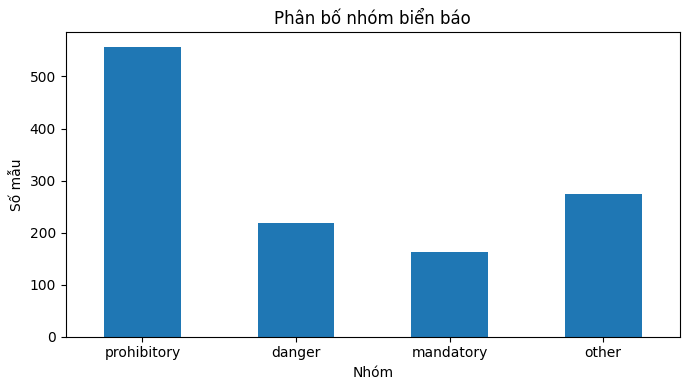

In [2]:
PROHIBITORY = [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 15, 16]
DANGER = [11, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
MANDATORY = [33, 34, 35, 36, 37, 38, 39, 40]
OTHER = [6, 12, 13, 14, 17, 32, 41, 42]
GROUP_ORDER = ["prohibitory", "danger", "mandatory", "other"]


def map_class_group(class_id):
    class_id = int(class_id)
    if class_id in PROHIBITORY:
        return "prohibitory"
    if class_id in DANGER:
        return "danger"
    if class_id in MANDATORY:
        return "mandatory"
    if class_id in OTHER:
        return "other"
    return "unknown"


def load_gtsdb_annotations(gt_path):
    columns = ["filename", "xmin", "ymin", "xmax", "ymax", "class_id"]
    df = pd.read_csv(gt_path, sep=";", names=columns)
    df[["xmin", "ymin", "xmax", "ymax", "class_id"]] = df[["xmin", "ymin", "xmax", "ymax", "class_id"]].astype(int)
    df["label_group"] = df["class_id"].apply(map_class_group)
    unknown = sorted(df.loc[df["label_group"] == "unknown", "class_id"].unique())
    if unknown:
        raise ValueError(f"Có ClassID chưa được map nhóm: {unknown}")
    return df


df = load_gtsdb_annotations(GT_PATH)
display(df.head())
print(f"Số lượng ảnh có annotation: {df['filename'].nunique()}")
print(f"Số lượng biển báo: {len(df)}")
display(df["label_group"].value_counts().reindex(GROUP_ORDER, fill_value=0).to_frame("count"))

ax = df["label_group"].value_counts().reindex(GROUP_ORDER, fill_value=0).plot(kind="bar", figsize=(7, 4))
ax.set_title("Phân bố nhóm biển báo")
ax.set_xlabel("Nhóm")
ax.set_ylabel("Số mẫu")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 4. Các hàm tiện ích


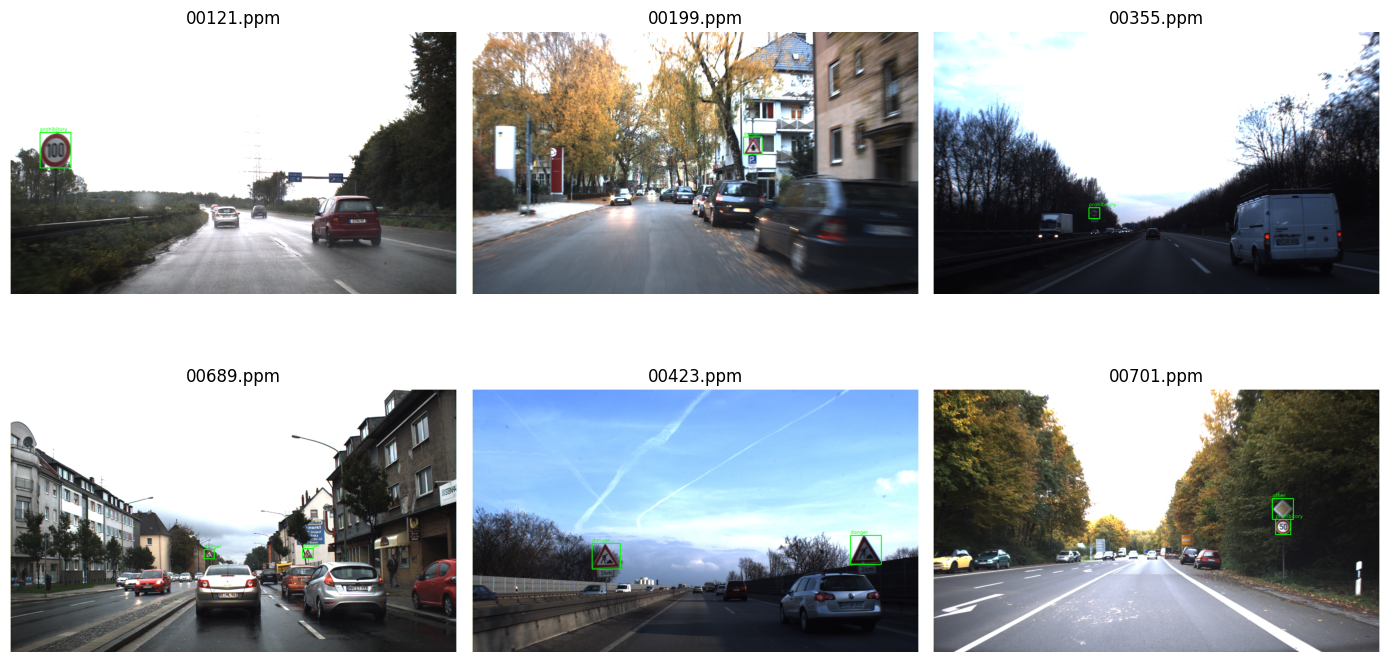

In [3]:
def read_image(path):
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Không đọc được ảnh: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def clip_box(box, width, height):
    xmin, ymin, xmax, ymax = [int(round(v)) for v in box]
    xmin = max(0, min(xmin, width - 1))
    ymin = max(0, min(ymin, height - 1))
    xmax = max(0, min(xmax, width - 1))
    ymax = max(0, min(ymax, height - 1))
    if xmax < xmin:
        xmin, xmax = xmax, xmin
    if ymax < ymin:
        ymin, ymax = ymax, ymin
    return xmin, ymin, xmax, ymax


def crop_box(image, box):
    h, w = image.shape[:2]
    xmin, ymin, xmax, ymax = clip_box(box, w, h)
    return image[ymin:ymax + 1, xmin:xmax + 1]


def compute_iou(boxA, boxB):
    ax1, ay1, ax2, ay2 = boxA
    bx1, by1, bx2, by2 = boxB
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0, ix2 - ix1 + 1) * max(0, iy2 - iy1 + 1)
    area_a = max(0, ax2 - ax1 + 1) * max(0, ay2 - ay1 + 1)
    area_b = max(0, bx2 - bx1 + 1) * max(0, by2 - by1 + 1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def draw_boxes(image, boxes, labels=None, color=(0, 255, 0), thickness=2):
    out = image.copy()
    labels = labels if labels is not None else [None] * len(boxes)
    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = [int(v) for v in box]
        cv2.rectangle(out, (x1, y1), (x2, y2), color, thickness)
        if label is not None:
            cv2.putText(out, str(label), (x1, max(15, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)
    return out


def show_sample_annotations(df, image_dir, n=6):
    files = df["filename"].drop_duplicates().sample(min(n, df["filename"].nunique()), random_state=RANDOM_STATE)
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    for ax, filename in zip(axes, files):
        image = read_image(image_dir / filename)
        rows = df[df["filename"] == filename]
        boxes = rows[["xmin", "ymin", "xmax", "ymax"]].values.tolist()
        labels = rows["label_group"].tolist()
        ax.imshow(draw_boxes(image, boxes, labels))
        ax.set_title(filename)
        ax.axis("off")
    for ax in axes[len(files):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


show_sample_annotations(df, DATA_ROOT, n=6)


## 5. Pipeline phát hiện vùng biển báo

Pipeline: ảnh gốc -> resize nếu cần -> HSV -> threshold đỏ/xanh/vàng -> morphology opening/closing -> Canny edge -> contour -> lọc contour theo diện tích, tỉ lệ, kích thước -> bbox ứng viên.

HSV được dùng vì màu biển báo ổn định hơn RGB khi thay đổi sáng. Morphology xóa nhiễu nhỏ và nối vùng bị đứt. Canny tìm biên cạnh mạnh của vật thể. Contour biến mask/edge thành vùng ứng viên có bbox.


In [4]:
def create_hsv_mask(image_rgb, preset="medium"):
    hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
    if preset == "tight":
        ranges = [((0, 90, 70), (8, 255, 255)), ((172, 90, 70), (179, 255, 255)), ((100, 90, 60), (125, 255, 255)), ((18, 80, 80), (32, 255, 255))]
    elif preset == "medium":
        ranges = [((0, 70, 50), (10, 255, 255)), ((170, 70, 50), (179, 255, 255)), ((95, 60, 45), (130, 255, 255)), ((15, 60, 60), (36, 255, 255))]
    elif preset == "wide":
        ranges = [((0, 45, 35), (14, 255, 255)), ((165, 45, 35), (179, 255, 255)), ((88, 40, 35), (138, 255, 255)), ((10, 40, 45), (42, 255, 255))]
    else:
        raise ValueError("preset phải là tight, medium hoặc wide")
    mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for lower, upper in ranges:
        mask = cv2.bitwise_or(mask, cv2.inRange(hsv, np.array(lower), np.array(upper)))
    return mask


def postprocess_mask(mask, kernel_size=5):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (int(kernel_size), int(kernel_size)))
    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)


def detect_edges(image_rgb, low=75, high=200):
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    return cv2.Canny(gray, int(low), int(high))


def find_candidate_boxes(mask, edges=None, min_area=80, max_area_ratio=0.2, min_edge_density=0.01):
    h, w = mask.shape[:2]
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area or area > max_area_ratio * h * w:
            continue

        x, y, bw, bh = cv2.boundingRect(cnt)
        if bw < 8 or bh < 8:
            continue

        aspect = bw / max(bh, 1)
        fill_ratio = area / max(bw * bh, 1)

        if edges is not None:
            roi_edges = edges[y:y+bh, x:x+bw]
            edge_density = np.count_nonzero(roi_edges) / max(roi_edges.size, 1)
        else:
            edge_density = 1.0

        if 0.35 <= aspect <= 2.5 and fill_ratio >= 0.08 and edge_density >= min_edge_density:
            boxes.append((x, y, x + bw - 1, y + bh - 1))

    return sorted(boxes, key=lambda b: (b[2]-b[0]+1)*(b[3]-b[1]+1), reverse=True)


def detect_sign_candidates(image_rgb, hsv_preset="medium", morph_kernel=5, canny_low=75, canny_high=200):
    mask = create_hsv_mask(image_rgb, preset=hsv_preset)
    clean_mask = postprocess_mask(mask, kernel_size=morph_kernel)
    edges = detect_edges(image_rgb, low=canny_low, high=canny_high)
    masked_edges = cv2.bitwise_and(edges, clean_mask)
    boxes = find_candidate_boxes(clean_mask, edges=masked_edges, min_edge_density=0.01)
    return boxes, {"mask": mask, "clean_mask": clean_mask, "edges": edges, "masked_edges": masked_edges}


def evaluate_detection_on_subset(df, image_dir, params, n_images=100):
    files = df["filename"].drop_duplicates().sort_values().tolist()[:n_images]
    ious, hits, box_counts = [], [], []
    for filename in tqdm(files, desc="Evaluate detection"):
        image = read_image(image_dir / filename)
        pred_boxes, _ = detect_sign_candidates(image, **params)
        gt_boxes = df[df["filename"] == filename][["xmin", "ymin", "xmax", "ymax"]].values.tolist()
        box_counts.append(len(pred_boxes))
        for gt_box in gt_boxes:
            best_iou = max([compute_iou(gt_box, pred_box) for pred_box in pred_boxes], default=0.0)
            ious.append(best_iou)
            hits.append(best_iou >= 0.5)
    return {"mean_iou": float(np.mean(ious)) if ious else 0.0, "recall_iou_0.5": float(np.mean(hits)) if hits else 0.0, "avg_boxes_per_image": float(np.mean(box_counts)) if box_counts else 0.0, "n_images": len(files), "n_gt_boxes": len(ious)}


DEFAULT_DET_PARAMS = {"hsv_preset": "medium", "morph_kernel": 5, "canny_low": 75, "canny_high": 200}
detection_baseline = evaluate_detection_on_subset(df, DATA_ROOT, DEFAULT_DET_PARAMS, n_images=min(100, df["filename"].nunique()))
display(pd.DataFrame([detection_baseline]))


Evaluate detection:   0%|          | 0/100 [00:00<?, ?it/s]

Evaluate detection: 100%|██████████| 100/100 [00:06<00:00, 15.39it/s]


,mean_iou,recall_iou_0.5,avg_boxes_per_image,n_images,n_gt_boxes
0,0.213291,0.214724,44.3,100,163


## 6. Ảnh trung gian


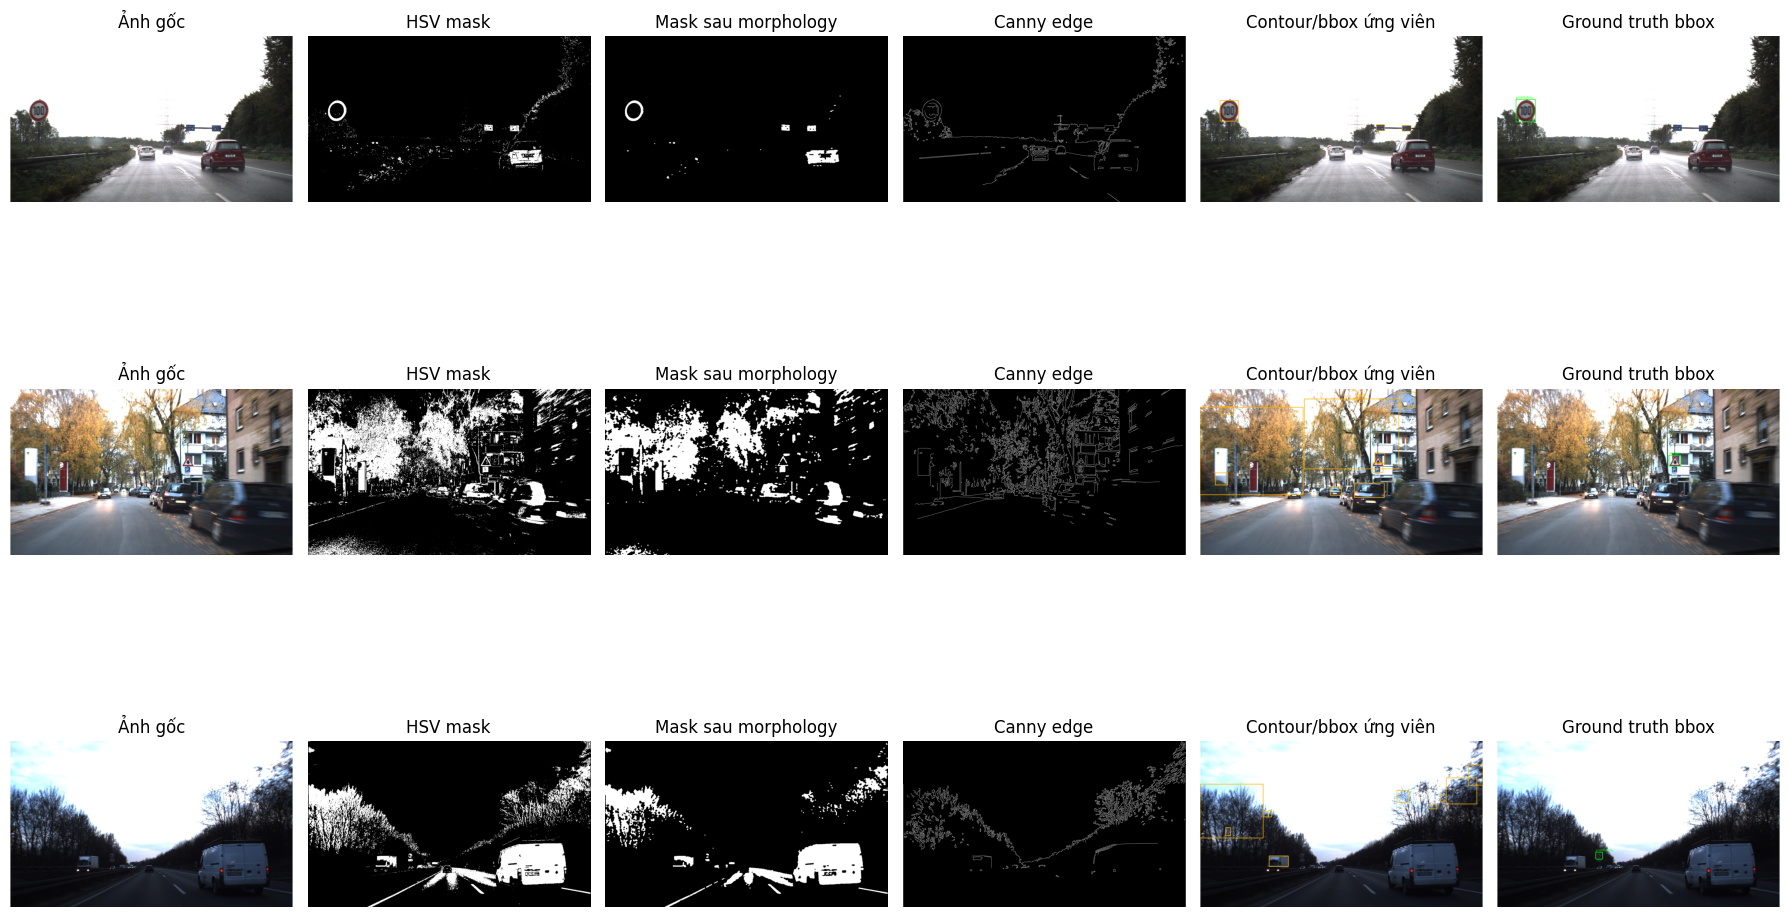

In [5]:
def visualize_detection_steps(df, image_dir, sample_files=None, params=None, n=3):
    params = params or DEFAULT_DET_PARAMS
    if sample_files is None:
        sample_files = df["filename"].drop_duplicates().sample(min(n, df["filename"].nunique()), random_state=RANDOM_STATE).tolist()
    fig, axes = plt.subplots(len(sample_files), 6, figsize=(18, 4 * len(sample_files)))
    if len(sample_files) == 1:
        axes = np.array([axes])
    titles = ["Ảnh gốc", "HSV mask", "Mask sau morphology", "Canny edge", "Contour/bbox ứng viên", "Ground truth bbox"]
    for r, filename in enumerate(sample_files):
        image = read_image(image_dir / filename)
        boxes, inter = detect_sign_candidates(image, **params)
        rows = df[df["filename"] == filename]
        gt_boxes = rows[["xmin", "ymin", "xmax", "ymax"]].values.tolist()
        panels = [image, inter["mask"], inter["clean_mask"], inter["edges"], draw_boxes(image, boxes[:10], color=(255, 180, 0)), draw_boxes(image, gt_boxes, rows["label_group"].tolist())]
        for c, panel in enumerate(panels):
            axes[r, c].imshow(panel, cmap="gray" if panel.ndim == 2 else None)
            axes[r, c].set_title(titles[c])
            axes[r, c].axis("off")
    plt.tight_layout()
    plt.show()


visualize_detection_steps(df, DATA_ROOT, n=3)


## 7. Khảo sát tham số detection

Mỗi khảo sát có bảng chỉ số, hình minh họa và nhận xét ngắn. `tight` ít nhiễu nhưng dễ bỏ sót, `wide` tăng recall nhưng có thể tăng false positive. Kernel nhỏ giữ chi tiết nhưng còn nhiễu, kernel lớn sạch hơn nhưng có thể mất vùng nhỏ. Canny threshold thấp tạo nhiều cạnh giả, threshold cao sạch hơn nhưng dễ mất biển báo mờ.


Evaluate detection: 100%|██████████| 100/100 [00:02<00:00, 36.93it/s]


,setting,mean_iou,recall_iou_0.5,avg_boxes_per_image,n_gt_boxes
0,tight,0.160095,0.171779,15.88,163
1,medium,0.213291,0.214724,44.30,163
2,wide,0.136608,0.104294,45.01,163


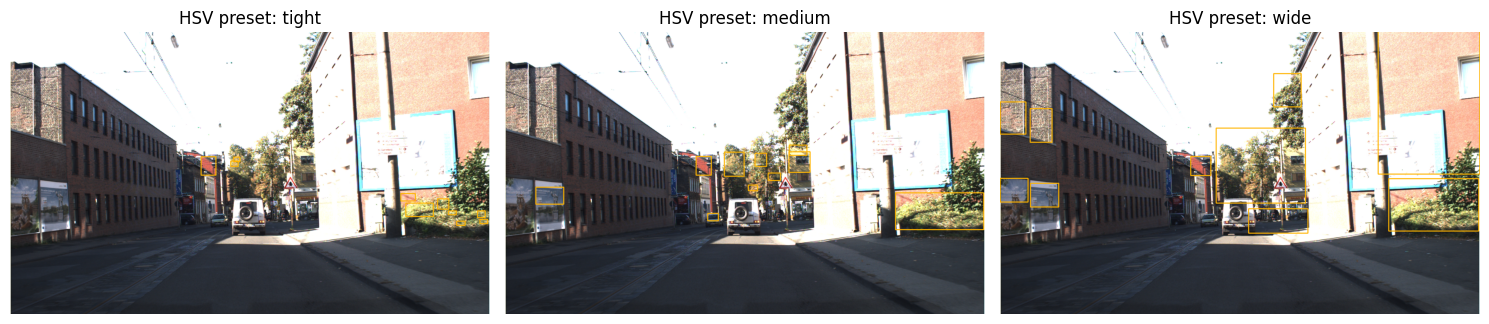

Nhận xét: chọn preset dựa trên trade-off giữa recall/IoU và số bbox trung bình.


Evaluate detection: 100%|██████████| 100/100 [00:02<00:00, 40.19it/s]


,setting,mean_iou,recall_iou_0.5,avg_boxes_per_image,n_gt_boxes
0,3,0.301084,0.312883,64.89,163
1,5,0.213291,0.214724,44.30,163
2,7,0.155589,0.165644,31.04,163


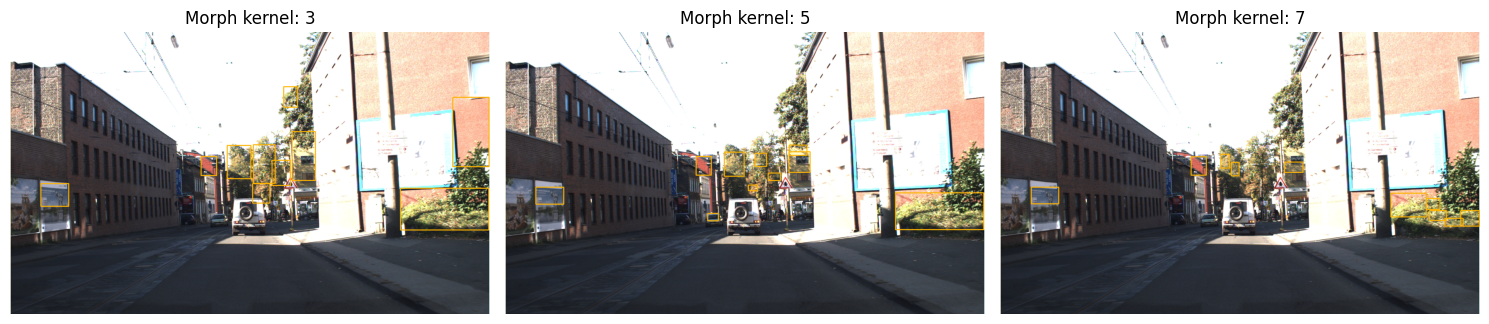

Nhận xét: kernel tốt là kernel làm sạch mask nhưng không xóa biển báo nhỏ.


Evaluate detection: 100%|██████████| 100/100 [00:02<00:00, 40.76it/s]


,setting,mean_iou,recall_iou_0.5,avg_boxes_per_image,n_gt_boxes
0,50-150,0.227585,0.233129,48.97,163
1,75-200,0.213291,0.214724,44.30,163
2,100-250,0.191093,0.190184,38.88,163


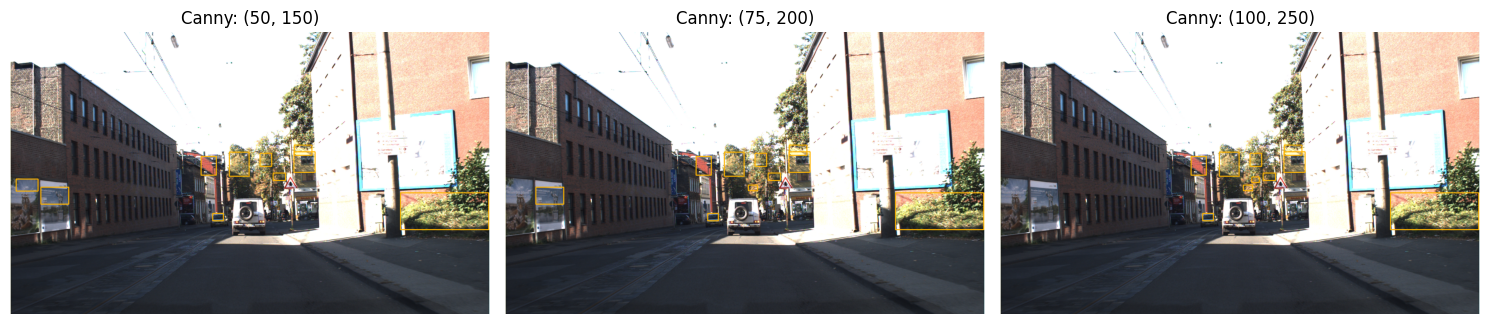

Nhận xét: threshold tốt cần giữ được biển báo mờ nhưng không làm bbox nền tăng quá nhiều.


In [6]:
DETECTION_EVAL_IMAGES = min(100, df["filename"].nunique())


def run_detection_sweep(param_name, values, base_params=None, n_images=DETECTION_EVAL_IMAGES):
    base_params = dict(base_params or DEFAULT_DET_PARAMS)
    rows = []
    for value in values:
        params = dict(base_params)
        if param_name == "canny":
            params["canny_low"], params["canny_high"] = value
            setting = f"{value[0]}-{value[1]}"
        else:
            params[param_name] = value
            setting = str(value)
        metrics = evaluate_detection_on_subset(df, DATA_ROOT, params, n_images=n_images)
        metrics["setting"] = setting
        rows.append(metrics)
    return pd.DataFrame(rows)


def visualize_param_effect(filename, settings, make_params, title):
    image = read_image(DATA_ROOT / filename)
    fig, axes = plt.subplots(1, len(settings), figsize=(5 * len(settings), 4))
    if len(settings) == 1:
        axes = [axes]
    for ax, setting in zip(axes, settings):
        boxes, _ = detect_sign_candidates(image, **make_params(setting))
        ax.imshow(draw_boxes(image, boxes[:10], color=(255, 180, 0)))
        ax.set_title(f"{title}: {setting}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


sample_file_for_sweep = df["filename"].drop_duplicates().iloc[0]

hsv_results = run_detection_sweep("hsv_preset", ["tight", "medium", "wide"])
display(hsv_results[["setting", "mean_iou", "recall_iou_0.5", "avg_boxes_per_image", "n_gt_boxes"]])
visualize_param_effect(sample_file_for_sweep, ["tight", "medium", "wide"], lambda v: {**DEFAULT_DET_PARAMS, "hsv_preset": v}, "HSV preset")
print("Nhận xét: chọn preset dựa trên trade-off giữa recall/IoU và số bbox trung bình.")

morph_results = run_detection_sweep("morph_kernel", [3, 5, 7])
display(morph_results[["setting", "mean_iou", "recall_iou_0.5", "avg_boxes_per_image", "n_gt_boxes"]])
visualize_param_effect(sample_file_for_sweep, [3, 5, 7], lambda v: {**DEFAULT_DET_PARAMS, "morph_kernel": v}, "Morph kernel")
print("Nhận xét: kernel tốt là kernel làm sạch mask nhưng không xóa biển báo nhỏ.")

canny_settings = [(50, 150), (75, 200), (100, 250)]
canny_results = run_detection_sweep("canny", canny_settings)
display(canny_results[["setting", "mean_iou", "recall_iou_0.5", "avg_boxes_per_image", "n_gt_boxes"]])
visualize_param_effect(sample_file_for_sweep, canny_settings, lambda v: {**DEFAULT_DET_PARAMS, "canny_low": v[0], "canny_high": v[1]}, "Canny")
print("Nhận xét: threshold tốt cần giữ được biển báo mờ nhưng không làm bbox nền tăng quá nhiều.")


## 8. Phân loại biển báo

Classification dùng crop từ ground truth bbox. Raw pixel resize rồi flatten, nhạy với dịch chuyển và ánh sáng. Color histogram biết phân bố màu nhưng mất cấu trúc không gian. HOG dùng histogram hướng gradient nên phù hợp vì biển báo khác nhau ở hình dạng/cấu trúc cạnh. Shape feature bổ sung edge density, aspect ratio, area ratio, circularity và số contour chính.


Build crops: 100%|██████████| 1213/1213 [00:35<00:00, 33.92it/s]


,count
prohibitory,557
danger,219
mandatory,163
other,274


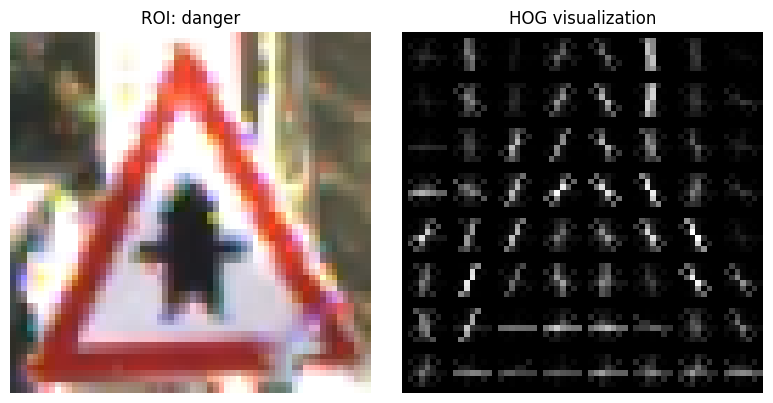

In [7]:
def build_classification_dataset(df, image_dir, image_size=(64, 64), max_per_class=None):
    work_df = df.copy()
    if max_per_class is not None:
        work_df = work_df.groupby("label_group", group_keys=False).apply(lambda g: g.sample(min(len(g), max_per_class), random_state=RANDOM_STATE))
    samples = []
    for _, row in tqdm(work_df.iterrows(), total=len(work_df), desc="Build crops"):
        image = read_image(image_dir / row["filename"])
        crop = crop_box(image, (row["xmin"], row["ymin"], row["xmax"], row["ymax"]))
        if crop.size == 0:
            continue
        crop = cv2.resize(crop, image_size, interpolation=cv2.INTER_AREA)
        samples.append({"image": crop, "label": row["label_group"], "filename": row["filename"], "class_id": row["class_id"]})
    return samples


def raw_pixel_feature(image_rgb, image_size=(32, 32)):
    resized = cv2.resize(image_rgb, image_size, interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)
    return (gray.astype(np.float32) / 255.0).ravel()


def color_hist_feature(image_rgb, bins=16):
    hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
    feats = []
    for ch, rg in enumerate([(0, 180), (0, 256), (0, 256)]):
        hist = cv2.calcHist([hsv], [ch], None, [bins], rg).ravel().astype(np.float32)
        feats.append(hist / (hist.sum() + 1e-8))
    return np.concatenate(feats)


def extract_hog_feature(image_rgb, pixels_per_cell=(8, 8), cells_per_block=(2, 2), orientations=9, visualize=False):
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, (64, 64), interpolation=cv2.INTER_AREA)
    return hog(gray, orientations=orientations, pixels_per_cell=pixels_per_cell, cells_per_block=cells_per_block, block_norm="L2-Hys", visualize=visualize, feature_vector=True)


def extract_shape_feature(image_rgb):
    resized = cv2.resize(image_rgb, (64, 64), interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 75, 200)
    edge_density = np.count_nonzero(edges) / edges.size
    mask = postprocess_mask(create_hsv_mask(resized, preset="medium"), kernel_size=3)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.array([edge_density, 1.0, 0.0, 0.0, 0.0], dtype=np.float32)
    cnt = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(cnt)
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    circularity = 4 * np.pi * area / (perimeter * perimeter + 1e-8)
    return np.array([edge_density, w / max(h, 1), area / mask.size, circularity, sum(cv2.contourArea(c) > 20 for c in contours)], dtype=np.float32)


def extract_features(image_rgb, mode):
    if mode == "raw":
        return raw_pixel_feature(image_rgb)
    if mode == "color":
        return color_hist_feature(image_rgb)
    if mode == "hog":
        return extract_hog_feature(image_rgb).astype(np.float32)
    if mode == "color_hog":
        return np.concatenate([color_hist_feature(image_rgb), extract_hog_feature(image_rgb)])
    if mode == "color_hog_shape":
        return np.concatenate([color_hist_feature(image_rgb), extract_hog_feature(image_rgb), extract_shape_feature(image_rgb)])
    raise ValueError(f"Không hỗ trợ mode: {mode}")


samples = build_classification_dataset(df, DATA_ROOT, image_size=(64, 64), max_per_class=None)
y = np.array([s["label"] for s in samples])
label_counts = pd.Series(y).value_counts()
if (label_counts < 2).any():
    raise ValueError(f"Có lớp quá ít mẫu để train/test stratify: {label_counts.to_dict()}")
display(label_counts.reindex(GROUP_ORDER, fill_value=0).to_frame("count"))

feature, hog_vis = extract_hog_feature(samples[0]["image"], visualize=True)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(samples[0]["image"]); axes[0].set_title(f"ROI: {samples[0]['label']}"); axes[0].axis("off")
axes[1].imshow(hog_vis, cmap="gray"); axes[1].set_title("HOG visualization"); axes[1].axis("off")
plt.tight_layout(); plt.show()


## 9. Train/test và so sánh model


Feature raw: 100%|██████████| 1213/1213 [00:00<00:00, 75642.15it/s]
c:\Users\ad\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
Feature color_hog_shape: 100%|██████████| 1213/1213 [00:01<00:00, 739.52it/s]


,model,accuracy,macro_precision,macro_recall,macro_f1
3,Color + HOG + SVM,1.000000,1.000000,1.000000,1.000000
2,HOG + SVM,1.000000,1.000000,1.000000,1.000000
4,Color + HOG + Shape + SVM,1.000000,1.000000,1.000000,1.000000
5,Color + HOG + Shape + KNN,0.976974,0.988014,0.958869,0.971829
0,Raw pixel + SVM,0.944079,0.928697,0.925994,0.926467
1,Color histogram + SVM,0.664474,0.643557,0.619302,0.609148


Model tốt nhất theo Macro F1: Color + HOG + SVM
              precision    recall  f1-score   support

      danger       1.00      1.00      1.00        55
   mandatory       1.00      1.00      1.00        41
       other       1.00      1.00      1.00        69
 prohibitory       1.00      1.00      1.00       139

    accuracy                           1.00       304
   macro avg       1.00      1.00      1.00       304
weighted avg       1.00      1.00      1.00       304



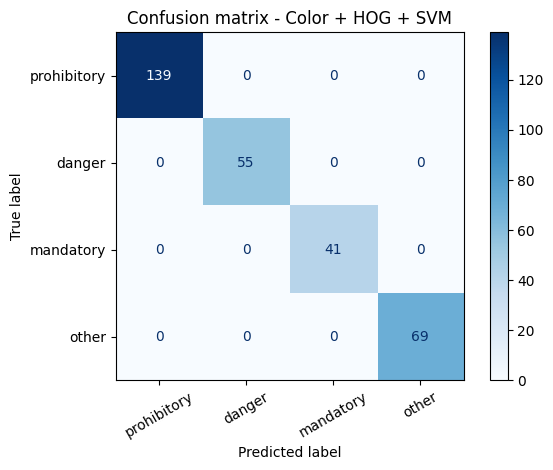

Nhận xét: dựa trên bảng vừa tính để kết luận HOG có cải thiện không, shape có giúp không, KNN so với SVM ra sao và lớp nào hay nhầm nhất.


In [ ]:
def make_feature_matrix(samples, mode):
    return np.vstack([extract_features(s["image"], mode) for s in tqdm(samples, desc=f"Feature {mode}")])


def train_evaluate_classifier(X, y, model_name):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
    if model_name.lower() == "knn":
        clf = Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=5))])
    elif model_name.lower() == "svc_linear":
        clf = Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE))])
    else:
        clf = Pipeline([("scaler", StandardScaler()), ("model", LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=10000))])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
    return {"classifier": clf, "accuracy": accuracy_score(y_test, y_pred), "macro_precision": precision, "macro_recall": recall, 
            "macro_f1": f1, "y_test": y_test, "y_pred": y_pred}


pipelines = [
    ("Raw pixel + SVM", "raw", "linear_svc"),
    ("Color histogram + SVM", "color", "linear_svc"),
    ("HOG + SVM", "hog", "linear_svc"),
    ("Color + HOG + SVM", "color_hog", "linear_svc"),
    ("Color + HOG + Shape + SVM", "color_hog_shape", "linear_svc"),
    ("Color + HOG + Shape + KNN", "color_hog_shape", "knn"),
]

rows, trained_models, feature_cache = [], {}, {}
for display_name, feature_mode, clf_name in pipelines:
    if feature_mode not in feature_cache:
        feature_cache[feature_mode] = make_feature_matrix(samples, feature_mode)
    result = train_evaluate_classifier(feature_cache[feature_mode], y, clf_name)
    rows.append({"model": display_name, "accuracy": result["accuracy"], "macro_precision": result["macro_precision"], 
                 "macro_recall": result["macro_recall"], "macro_f1": result["macro_f1"]})
    trained_models[display_name] = result

results_df = pd.DataFrame(rows)
display(results_df.sort_values("macro_f1", ascending=False))
best_model_name = results_df.sort_values("macro_f1", ascending=False).iloc[0]["model"]
best = trained_models[best_model_name]
print(f"Model tốt nhất theo Macro F1: {best_model_name}")
print(classification_report(best["y_test"], best["y_pred"], zero_division=0))
cm = confusion_matrix(best["y_test"], best["y_pred"], labels=GROUP_ORDER)
ConfusionMatrixDisplay(cm, display_labels=GROUP_ORDER).plot(cmap="Blues", xticks_rotation=30)
plt.title(f"Confusion matrix - {best_model_name}")
plt.tight_layout(); plt.show()
print("Nhận xét: dựa trên bảng vừa tính để kết luận HOG có cải thiện không, shape có giúp không, KNN so với SVM ra sao và lớp nào hay nhầm nhất.")


## 10. Khảo sát tham số classification

### 10.1 HOG pixels_per_cell

Cell nhỏ chi tiết hơn nhưng feature dài, dễ overfit/chậm. Cell lớn gọn hơn nhưng mất chi tiết nhỏ. `(8,8)` thường cân bằng.

### 10.2 SVM C

`C` nhỏ tạo margin rộng, ít overfit nhưng có thể underfit. `C` lớn phạt lỗi mạnh hơn, có thể fit tốt train nhưng dễ overfit.


In [9]:
def extract_color_hog_with_ppc(image_rgb, pixels_per_cell):
    return np.concatenate([color_hist_feature(image_rgb), extract_hog_feature(image_rgb, pixels_per_cell=pixels_per_cell)])


hog_ppc_rows = []
for ppc in [(4, 4), (8, 8), (16, 16)]:
    X_ppc = np.vstack([extract_color_hog_with_ppc(s["image"], ppc) for s in tqdm(samples, desc=f"HOG {ppc}")])
    result = train_evaluate_classifier(X_ppc, y, "linear_svc")
    hog_ppc_rows.append({"pixels_per_cell": str(ppc), "accuracy": result["accuracy"], "macro_precision": result["macro_precision"], "macro_recall": result["macro_recall"], "macro_f1": result["macro_f1"], "n_features": X_ppc.shape[1]})
display(pd.DataFrame(hog_ppc_rows))


def train_eval_linear_svm_C(X, y, C):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
    clf = Pipeline([("scaler", StandardScaler()), ("model", LinearSVC(C=C, random_state=RANDOM_STATE, max_iter=10000))])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
    return accuracy_score(y_test, y_pred), precision, recall, f1


X_chs = feature_cache["color_hog_shape"] if "color_hog_shape" in feature_cache else make_feature_matrix(samples, "color_hog_shape")
svm_c_rows = []
for C in [0.1, 1, 10]:
    acc, prec, rec, f1 = train_eval_linear_svm_C(X_chs, y, C)
    svm_c_rows.append({"C": C, "accuracy": acc, "macro_precision": prec, "macro_recall": rec, "macro_f1": f1})
display(pd.DataFrame(svm_c_rows))


HOG (16, 16): 100%|██████████| 1213/1213 [00:00<00:00, 2210.96it/s]


,pixels_per_cell,accuracy,macro_precision,macro_recall,macro_f1,n_features
0,"(4, 4)",0.990132,0.982955,0.992780,0.987540,8148
1,"(8, 8)",1.000000,1.000000,1.000000,1.000000,1812
2,"(16, 16)",0.983553,0.983010,0.980585,0.981748,372


,C,accuracy,macro_precision,macro_recall,macro_f1
0,0.1,1.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0,1.0
2,10.0,1.0,1.0,1.0,1.0


## 11. Phần nâng cao để lấy 2 điểm cuối: Hard Negative Mining cho HOG + Linear SVM detector

HOG + SVM detector ban đầu dễ nhầm các vùng nền có cạnh mạnh như cửa sổ, biển quảng cáo, đèn xe. Hard Negative Mining chạy model vòng 1 trên ảnh train/validation, lấy các vùng background được chấm điểm cao nhưng `IoU < 0.1` với GT làm hard negatives, rồi train lại. Đây là vòng lặp huấn luyện dựa trên false positive, thể hiện hiểu về classifier margin và lỗi false positive trong object detection truyền thống.


Binary HOG: 100%|██████████| 1163/1163 [00:01<00:00, 1065.39it/s]
c:\Users\ad\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
Mine hard negatives: 100%|██████████| 100/100 [00:03<00:00, 26.05it/s]


Số hard negatives khai thác được: 222


Binary HOG: 100%|██████████| 1385/1385 [00:01<00:00, 1134.49it/s]
c:\Users\ad\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
Eval binary detector: 100%|██████████| 100/100 [00:04<00:00, 20.68it/s]


,stage,false_positive,precision,recall,f1
0,before_hnm,314,0.092486,0.196319,0.125737
1,after_hnm,19,0.604167,0.177914,0.274882


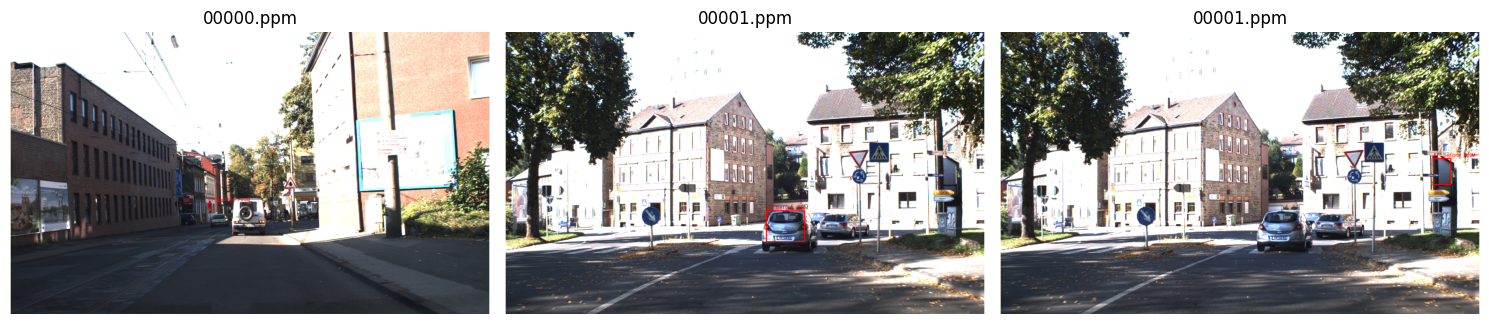

In [10]:
MAX_IMAGES_FOR_HNM = 100
MAX_HARD_NEGATIVES = 500
HNM_CROP_SIZE = (64, 64)


def sample_negative_crops(image_rgb, gt_boxes, n_samples=20, crop_size=(64, 64), max_iou=0.1):
    h, w = image_rgb.shape[:2]
    cw, ch = crop_size
    negatives, attempts = [], 0
    while len(negatives) < n_samples and attempts < n_samples * 50:
        attempts += 1
        cur_w, cur_h = min(cw, w), min(ch, h)
        x1 = random.randint(0, max(0, w - cur_w))
        y1 = random.randint(0, max(0, h - cur_h))
        box = (x1, y1, x1 + cur_w - 1, y1 + cur_h - 1)
        if max([compute_iou(box, gt) for gt in gt_boxes], default=0.0) <= max_iou:
            negatives.append(cv2.resize(crop_box(image_rgb, box), crop_size, interpolation=cv2.INTER_AREA))
    return negatives


def build_binary_sign_dataset(df, image_dir, max_images=MAX_IMAGES_FOR_HNM, negatives_per_image=10):
    files = df["filename"].drop_duplicates().sort_values().tolist()[:max_images]
    images, labels = [], []
    for filename in tqdm(files, desc="Binary dataset"):
        image = read_image(image_dir / filename)
        gt_boxes = df[df["filename"] == filename][["xmin", "ymin", "xmax", "ymax"]].values.tolist()
        for gt in gt_boxes:
            images.append(cv2.resize(crop_box(image, gt), HNM_CROP_SIZE, interpolation=cv2.INTER_AREA))
            labels.append(1)
        negs = sample_negative_crops(image, gt_boxes, n_samples=negatives_per_image, crop_size=HNM_CROP_SIZE, max_iou=0.1)
        images.extend(negs)
        labels.extend([0] * len(negs))
    return images, np.array(labels, dtype=int)


def train_binary_hog_svm(images, labels, C=1.0):
    X = np.vstack([extract_hog_feature(img) for img in tqdm(images, desc="Binary HOG")])
    clf = Pipeline([("scaler", StandardScaler()), ("model", LinearSVC(C=C, random_state=RANDOM_STATE, max_iter=10000))])
    clf.fit(X, labels)
    return clf


def score_binary_crops(clf, crops):
    X = np.vstack([extract_hog_feature(crop) for crop in crops])
    return clf.decision_function(X)


def mine_hard_negatives(clf, df, image_dir, max_images=MAX_IMAGES_FOR_HNM, max_hard_negatives=MAX_HARD_NEGATIVES):
    hard_negs = []
    files = df["filename"].drop_duplicates().sort_values().tolist()[:max_images]
    for filename in tqdm(files, desc="Mine hard negatives"):
        image = read_image(image_dir / filename)
        gt_boxes = df[df["filename"] == filename][["xmin", "ymin", "xmax", "ymax"]].values.tolist()
        candidate_boxes, _ = detect_sign_candidates(image, **DEFAULT_DET_PARAMS)
        crops = []
        for box in candidate_boxes[:30]:
            if max([compute_iou(box, gt) for gt in gt_boxes], default=0.0) < 0.1:
                crops.append(cv2.resize(crop_box(image, box), HNM_CROP_SIZE, interpolation=cv2.INTER_AREA))
        if not crops:
            continue
        scores = score_binary_crops(clf, crops)
        for idx in np.argsort(scores)[::-1]:
            if scores[idx] > 0:
                hard_negs.append(crops[idx])
                if len(hard_negs) >= max_hard_negatives:
                    return hard_negs
    return hard_negs


def evaluate_binary_detector(clf, df, image_dir, max_images=MAX_IMAGES_FOR_HNM):
    files = df["filename"].drop_duplicates().sort_values().tolist()[:max_images]
    y_true, y_pred, examples = [], [], []
    for filename in tqdm(files, desc="Eval binary detector"):
        image = read_image(image_dir / filename)
        gt_boxes = df[df["filename"] == filename][["xmin", "ymin", "xmax", "ymax"]].values.tolist()
        candidate_boxes, _ = detect_sign_candidates(image, **DEFAULT_DET_PARAMS)
        crops = [cv2.resize(crop_box(image, b), HNM_CROP_SIZE, interpolation=cv2.INTER_AREA) for b in candidate_boxes[:50]]
        pred_positive = []
        if crops:
            scores = score_binary_crops(clf, crops)
            pred_positive = [candidate_boxes[i] for i, s in enumerate(scores) if s > 0]
        for gt in gt_boxes:
            best_iou = max([compute_iou(gt, p) for p in pred_positive], default=0.0)
            y_true.append(1); y_pred.append(1 if best_iou >= 0.5 else 0)
        for box in pred_positive:
            if max([compute_iou(box, gt) for gt in gt_boxes], default=0.0) < 0.1:
                y_true.append(0); y_pred.append(1)
                if len(examples) < 3:
                    examples.append((filename, box))
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    fp = int(np.sum((np.array(y_true) == 0) & (np.array(y_pred) == 1)))
    return {"false_positive": fp, "precision": precision, "recall": recall, "f1": f1, "examples": examples}


binary_images, binary_labels = build_binary_sign_dataset(df, DATA_ROOT)
clf_before_hnm = train_binary_hog_svm(binary_images, binary_labels)
metrics_before = evaluate_binary_detector(clf_before_hnm, df, DATA_ROOT)
hard_negatives = mine_hard_negatives(clf_before_hnm, df, DATA_ROOT)
print(f"Số hard negatives khai thác được: {len(hard_negatives)}")
if hard_negatives:
    clf_after_hnm = train_binary_hog_svm(binary_images + hard_negatives, np.concatenate([binary_labels, np.zeros(len(hard_negatives), dtype=int)]))
    metrics_after = evaluate_binary_detector(clf_after_hnm, df, DATA_ROOT)
else:
    metrics_after = metrics_before.copy()

display(pd.DataFrame([
    {"stage": "before_hnm", **{k: v for k, v in metrics_before.items() if k != "examples"}},
    {"stage": "after_hnm", **{k: v for k, v in metrics_after.items() if k != "examples"}},
]))

examples = metrics_before.get("examples", [])[:3]
if examples:
    fig, axes = plt.subplots(1, len(examples), figsize=(5 * len(examples), 4))
    if len(examples) == 1:
        axes = [axes]
    for ax, (filename, box) in zip(axes, examples):
        image = read_image(DATA_ROOT / filename)
        ax.imshow(draw_boxes(image, [box], ["FP before HNM"], color=(255, 0, 0)))
        ax.set_title(filename); ax.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("Không có ví dụ false positive trong subset hiện tại.")


## 12. GrabCut refinement phụ trợ

GrabCut kết hợp mô hình màu foreground/background và graph cut. Khác với threshold HSV, GrabCut tối ưu theo vùng và biên nên có thể tách vật thể tốt hơn trong nền phức tạp. Nếu bbox khởi tạo sai hoặc foreground/background màu giống nhau, GrabCut có thể thất bại.


GrabCut 5: 100%|██████████| 50/50 [01:41<00:00,  2.02s/it]


,grabcut_iters,mean_iou_before,mean_iou_after,delta_iou
0,1,0.253181,0.254339,0.001157
1,3,0.253181,0.257011,0.003830
2,5,0.253181,0.260552,0.007371


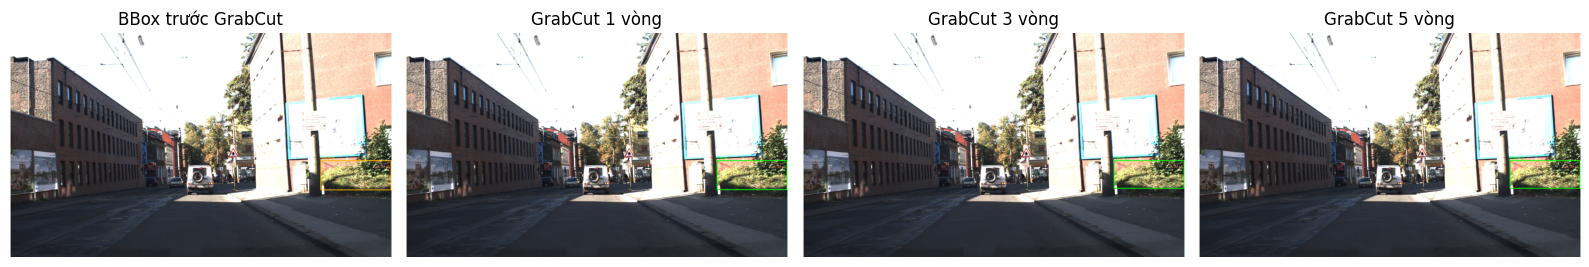

In [11]:
def grabcut_refine_box(image_rgb, box, iter_count=3):
    h, w = image_rgb.shape[:2]
    x1, y1, x2, y2 = clip_box(box, w, h)
    rect_w, rect_h = max(2, x2 - x1 + 1), max(2, y2 - y1 + 1)
    mask = np.zeros((h, w), np.uint8)
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)
    try:
        cv2.grabCut(cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR), mask, (x1, y1, rect_w, rect_h), bgd_model, fgd_model, iter_count, cv2.GC_INIT_WITH_RECT)
    except cv2.error:
        return box, np.zeros((h, w), dtype=np.uint8)
    fg = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 255, 0).astype("uint8")
    ys, xs = np.where(fg > 0)
    if len(xs) == 0 or len(ys) == 0:
        return box, fg
    return (int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())), fg


def evaluate_grabcut(df, image_dir, iter_values=(1, 3, 5), n_images=50):
    files = df["filename"].drop_duplicates().sort_values().tolist()[:n_images]
    rows = []
    for iters in iter_values:
        before_ious, after_ious = [], []
        for filename in tqdm(files, desc=f"GrabCut {iters}"):
            image = read_image(image_dir / filename)
            pred_boxes, _ = detect_sign_candidates(image, **DEFAULT_DET_PARAMS)
            gt_boxes = df[df["filename"] == filename][["xmin", "ymin", "xmax", "ymax"]].values.tolist()
            for gt in gt_boxes:
                if not pred_boxes:
                    before_ious.append(0.0); after_ious.append(0.0); continue
                best_pred = max(pred_boxes, key=lambda b: compute_iou(gt, b))
                refined, _ = grabcut_refine_box(image, best_pred, iter_count=iters)
                before_ious.append(compute_iou(gt, best_pred))
                after_ious.append(compute_iou(gt, refined))
        rows.append({"grabcut_iters": iters, "mean_iou_before": float(np.mean(before_ious)), "mean_iou_after": float(np.mean(after_ious)), "delta_iou": float(np.mean(after_ious) - np.mean(before_ious))})
    return pd.DataFrame(rows)


grabcut_results = evaluate_grabcut(df, DATA_ROOT, iter_values=[1, 3, 5], n_images=min(50, df["filename"].nunique()))
display(grabcut_results)

filename = df["filename"].drop_duplicates().iloc[0]
image = read_image(DATA_ROOT / filename)
pred_boxes, _ = detect_sign_candidates(image, **DEFAULT_DET_PARAMS)
if pred_boxes:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(draw_boxes(image, [pred_boxes[0]], ["before"], color=(255, 180, 0)))
    axes[0].set_title("BBox trước GrabCut"); axes[0].axis("off")
    for ax, iters in zip(axes[1:], [1, 3, 5]):
        refined, _ = grabcut_refine_box(image, pred_boxes[0], iter_count=iters)
        ax.imshow(draw_boxes(image, [refined], [f"iter={iters}"], color=(0, 255, 0)))
        ax.set_title(f"GrabCut {iters} vòng"); ax.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("Không có bbox ứng viên để minh họa GrabCut trên ảnh mẫu.")


## 13. Tổng kết kết quả

Sau khi chạy notebook với dataset thật, kết luận dựa trên các bảng đã tính:

- Giả thuyết đúng, sai hay đúng một phần?
- Pipeline nào tốt nhất?
- HOG có thực sự giúp cải thiện không?
- Tham số nào ảnh hưởng rõ nhất?
- Hard negative mining có giảm false positive không?
- GrabCut có cải thiện IoU không?

Các trường hợp thất bại thường gặp: biển báo quá nhỏ, bị mờ, thiếu sáng, nền cùng màu, biển bị che khuất. Hướng cải thiện gồm tăng dữ liệu, cân bằng lớp, dùng multi-scale sliding window tốt hơn, hoặc dùng SIFT/BoW/CNN như nhánh mở rộng có giải thích, không dùng hộp đen thay thế pipeline CV.


## 14. Chất lượng code

Notebook có hàm rõ ràng, dùng `random_state=42`, có bảng kết quả dạng DataFrame, `classification_report`, confusion matrix, kiểm tra lỗi khi một lớp quá ít mẫu, và các biến giới hạn subset để tránh chạy quá lâu. Các cell nặng như Hard Negative Mining dùng `MAX_IMAGES_FOR_HNM = 100` và `MAX_HARD_NEGATIVES = 500`.
